# Model-Geometry GO And Mapper Stress Tests

This notebook keeps the BRCA GO-coherence check and tests whether score-conditioned mapper ordering survives score permutation.

## Project Root And Imports

Load project utilities and plotting style.

In [1]:
from __future__ import annotations

import pickle as pkl
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from SAE.manifold.core import local_manifold_projection, parse_ks_config
from SAE.SAE_training.utils.data import (
    concat_gene2vec_pair_embeddings,
    concat_geneformer_pair_embeddings,
    concat_slformer_pair_embeddings,
    gene2vec_pair_mask,
    load_cancer_id_map,
    load_gene2vec_embeddings,
    zscore_matrix,
)
from SAE.manifold.utils.enrichment import (
    best_cluster_summary,
    cluster_failure_diagnostic,
    cluster_go_background_summary,
    configure_publication_plots,
    gene_level_matrix,
    load_go_symbol_annotations,
    plot_brca1_mapper_panel,
    mapper_permutation_stress_test,
    plot_mapper_model_summary,
    plot_permutation_stress,
    summarize_permutation_stress,
    region_gene_set,
    region_go_coherence,
    run_gmm_gene_clustering,
)
from SAE.LLM_pipeline.utils.general import find_pair_index

configure_publication_plots()
print(f"Project root: {PROJECT_ROOT}")


Project root: /home/guoyu/SLformer_interpretation


## Configuration

The stress test fits the same score-conditioned mapper after shuffling scores.

In [2]:
SEED = 42
TARGET_CANCER = "BRCA"
TARGET_PAIRS = [
    ("BRCA1", "PARP1", "BRCA"),
    ("BRCA2", "PARP1", "BRCA"),
    ("PARP1", "RAD51", "BRCA"),
    ("CHEK2", "PARP1", "BRCA"),
]
BRCA1_PAIR = ("BRCA1", "PARP1", "BRCA")
FIT_K = 300
TARGET_SUMMARY_K = 100
NULL_SAMPLES = 300
GMM_COMPONENTS = 6
CLUSTER_BACKGROUND_SAMPLES = 10_000
MIN_CLUSTER_GENES = 5
MIN_SHARED_GO_TERMS = 3
PERMUTATION_KS = (10, 30, 70, 100)
N_PERMUTATIONS = 30

MANIFOLD_CONFIG = PROJECT_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml"
manifold_file_cfg = yaml.safe_load(MANIFOLD_CONFIG.read_text(encoding="utf-8"))
comparison_cfg = manifold_file_cfg["comparison"]
projection_cfg = manifold_file_cfg["projection"]
MANIFOLD_TANGENT_DIM = int(projection_cfg["tangent_dim"])
MANIFOLD_RIDGE_RHO = float(comparison_cfg["ridge_rho"])
MANIFOLD_NERVE_LENS_DIMS = tuple(int(dim) for dim in comparison_cfg["nerve_lens_dims"])
MANIFOLD_NERVE_COVERS = int(comparison_cfg["nerve_covers"])
MANIFOLD_NERVE_OVERLAP = float(comparison_cfg["nerve_overlap"])
MANIFOLD_NERVE_COVER_MODE = str(comparison_cfg["nerve_cover_mode"])
MANIFOLD_NERVE_COVER_CORE_FRACTION = float(comparison_cfg["nerve_cover_core_fraction"])
MANIFOLD_NERVE_CLUSTER_MODE = str(comparison_cfg["nerve_cluster_mode"])
MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE = float(comparison_cfg["nerve_dbscan_eps_quantile"])
MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES = int(comparison_cfg["nerve_dbscan_min_samples"])
MANIFOLD_NERVE_FALLBACK_UNREACHABLE = bool(comparison_cfg["nerve_fallback_unreachable"])
TARGET_KS = parse_ks_config(comparison_cfg["ks"], fit_k=FIT_K)

SLFORMER_TRANSFORMER_EMB_PKL = PROJECT_ROOT / "data" / "all_SL" / "mix_slformer_kg_transformeremb.pkl"
GENEFORMER_EMB_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "geneformer_emb.pkl"
GENE2ID_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "gene2id.pkl"
CANCER_LIST_TXT = PROJECT_ROOT / "data" / "saved_data" / "map" / "cancer_list.txt"
GENEFORMER_PREDICTION_CSVS = [PROJECT_ROOT / "data" / "all_SL" / f"pred_mix_geneformer_nokg_cv{fold}.csv" for fold in range(1, 6)]
SLFORMER_LABEL_CSVS = [PROJECT_ROOT / "data" / "merged_pred_true_slformer" / f"merged_pred_true_fold_{fold}.csv" for fold in range(1, 6)]
GENE2VEC_TXT = Path("/home/tinglu/Projects/Gene2vec/pre_trained_emb/gene2vec_dim_200_iter_9_w2v.txt")
GO_GAF = Path("/home/jienihu/sc/SLformer/data/GO/goa_human.gaf")
GO_ID_MAPPING = Path("/home/jienihu/sc/SLformer/data/GO/idmapping_2024_11_09.tsv")

print({
    "target_pairs": [f"{c}:{a}-{b}" for a, b, c in TARGET_PAIRS],
    "fit_k": FIT_K,
    "target_ks": TARGET_KS,
    "null_samples": NULL_SAMPLES,
    "cluster_background_samples": CLUSTER_BACKGROUND_SAMPLES,
    "cover_mode": MANIFOLD_NERVE_COVER_MODE,
    "cover_core_fraction": MANIFOLD_NERVE_COVER_CORE_FRACTION,
    "cluster_mode": MANIFOLD_NERVE_CLUSTER_MODE,
    "fallback_unreachable": MANIFOLD_NERVE_FALLBACK_UNREACHABLE,
    "permutation_mapper_fits": len(TARGET_PAIRS) * len(model_matrices) * N_PERMUTATIONS if "model_matrices" in globals() else len(TARGET_PAIRS) * 3 * N_PERMUTATIONS,
})


{'target_pairs': ['BRCA:BRCA1-PARP1', 'BRCA:BRCA2-PARP1', 'BRCA:PARP1-RAD51', 'BRCA:CHEK2-PARP1'], 'fit_k': 300, 'target_ks': (10, 20, 30, 50, 70, 100, 150, 200), 'null_samples': 300, 'cluster_background_samples': 10000, 'cover_mode': 'all-intersecting', 'cover_core_fraction': 0.1, 'cluster_mode': 'cover', 'fallback_unreachable': True, 'permutation_mapper_fits': 360}


## Load Aligned Model Matrices

Use the three-model row intersection and SLformer score/label metadata.

In [3]:
geneformer_prediction_parts = [pd.read_csv(path) for path in GENEFORMER_PREDICTION_CSVS]
meta = pd.concat(geneformer_prediction_parts, ignore_index=True).reset_index(drop=True)
meta["fold"] = np.repeat(np.arange(len(geneformer_prediction_parts)), [len(part) for part in geneformer_prediction_parts])
meta = meta.rename(columns={"score": "geneformer_pred_score"})

label_parts = [pd.read_csv(path) for path in SLFORMER_LABEL_CSVS]
label_table = pd.concat(label_parts, ignore_index=True).reset_index(drop=True)
meta["label"] = label_table["label"].astype(int).to_numpy()
meta["slformer_pred_score"] = label_table["pred_score"].astype(np.float32).to_numpy()
scores_all = meta["slformer_pred_score"].to_numpy(dtype=np.float32)
labels_all = meta["label"].to_numpy(dtype=np.int64)

with SLFORMER_TRANSFORMER_EMB_PKL.open("rb") as f:
    slformer_emb_folds = pkl.load(f)
with GENEFORMER_EMB_PKL.open("rb") as f:
    geneformer_emb = pkl.load(f)
with GENE2ID_PKL.open("rb") as f:
    gene2id_map = pkl.load(f)

cancer2id_map = load_cancer_id_map(CANCER_LIST_TXT)
gene2vec = load_gene2vec_embeddings(GENE2VEC_TXT)

gene2vec_mask = gene2vec_pair_mask(meta, gene2vec)
geneformer_mask = (
    meta["primary_gene"].astype(str).isin(gene2id_map).to_numpy()
    & meta["partner_gene"].astype(str).isin(gene2id_map).to_numpy()
    & meta["cancer"].astype(str).isin(cancer2id_map).to_numpy()
)
aligned_mask = gene2vec_mask & geneformer_mask

meta_aligned = meta.loc[aligned_mask].reset_index(drop=True)
scores = scores_all[aligned_mask]
labels = labels_all[aligned_mask]
X_slformer = concat_slformer_pair_embeddings(slformer_emb_folds)[aligned_mask]
X_geneformer = concat_geneformer_pair_embeddings(meta_aligned, geneformer_emb, gene2id_map, cancer2id_map)
X_gene2vec = concat_gene2vec_pair_embeddings(meta_aligned, gene2vec)

X_slformer_n, _, _ = zscore_matrix(X_slformer)
X_geneformer_n, _, _ = zscore_matrix(X_geneformer)
X_gene2vec_n, _, _ = zscore_matrix(X_gene2vec)
model_matrices = {"SLformer": X_slformer_n, "Geneformer": X_geneformer_n, "Gene2Vec": X_gene2vec_n}

symbol_annotations = load_go_symbol_annotations(GO_GAF, GO_ID_MAPPING)
print({
    "all_rows": int(len(meta)),
    "aligned_rows": int(len(meta_aligned)),
    "removed_rows": int((~aligned_mask).sum()),
    "brca_rows": int((meta_aligned["cancer"].astype(str) == TARGET_CANCER).sum()),
})
for model_name, X_model in model_matrices.items():
    print(f"{model_name}: {X_model.shape}")

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/goatools/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


HMS:0:00:16.780574 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 


36129 IDs in loaded association branch, BP
{'all_rows': 58620, 'aligned_rows': 58474, 'removed_rows': 146, 'brca_rows': 717}
SLformer: (58474, 1024)
Geneformer: (58474, 512)
Gene2Vec: (58474, 400)


## BRCA Gene Clustering Check

Rerun the old 0.52-vs-background GO-coherence result and print why single-gene clustering is brittle.

In [4]:
cluster_parts = []
gene_tables = {}
cluster_backgrounds = {}
for model_name, X_model in model_matrices.items():
    gene_table, X_gene = gene_level_matrix(meta_aligned, X_model, cancer=TARGET_CANCER)
    gene_tables[model_name] = gene_table
    clusters = run_gmm_gene_clustering(gene_table, X_gene, n_components=GMM_COMPONENTS, seed=SEED)
    cluster_summary_model, background = cluster_go_background_summary(
        clusters,
        symbol_annotations,
        model=model_name,
        background_samples=CLUSTER_BACKGROUND_SAMPLES,
        min_cluster_genes=MIN_CLUSTER_GENES,
        min_shared_terms=MIN_SHARED_GO_TERMS,
        seed=SEED,
    )
    cluster_parts.append(cluster_summary_model)
    cluster_backgrounds[model_name] = background

cluster_summary = pd.concat(cluster_parts, ignore_index=True)
cluster_best = best_cluster_summary(cluster_summary)
cluster_diagnostic = cluster_failure_diagnostic(gene_tables, cluster_summary)
print(cluster_best[["model", "cluster", "n_annotated_genes", "n_gene_pairs", "mean_shared_go_terms", "background_mean", "mannwhitney_p"]].round(4).to_string(index=False))
print("\nWhy gene-level clustering is weak here:")
print(cluster_diagnostic.round(4).to_string(index=False))

     model cluster  n_annotated_genes  n_gene_pairs  mean_shared_go_terms  background_mean  mannwhitney_p
  SLformer       0                 40           780                0.5256           0.2091         0.0000
Geneformer       0                 79          3081                0.2817           0.2091         0.0000
  Gene2Vec       2                 56          1540                0.2636           0.2091         0.0007

Why gene-level clustering is weak here:
     model  n_genes  median_gene_occurrences  single_occurrence_fraction  best_cluster_gene_fraction  median_cluster_go_mean  max_cluster_go_mean
  SLformer      373                      1.0                      0.8713                      0.1823                  0.1893               0.5256
Geneformer      373                      1.0                      0.8713                      0.2761                  0.2429               0.2817
  Gene2Vec      373                      1.0                      0.8713                      0.3

## Mapper-Distance Neighbourhoods

Compute target-pair GO coherence from score-conditioned mapper prefixes.

In [5]:
def mapper_projection_for_target(X_model: np.ndarray, target_idx: int) -> pd.DataFrame:
    nn = NearestNeighbors(n_neighbors=FIT_K + 1, metric="cosine").fit(X_model)
    neighbours = nn.kneighbors(X_model[target_idx : target_idx + 1], return_distance=False)[0]
    fit_indices = neighbours[neighbours != int(target_idx)][:FIT_K]
    mapper = local_manifold_projection(
        X_model,
        scores,
        labels,
        anchor_index=target_idx,
        fit_indices=fit_indices,
        display_k=FIT_K,
        tangent_dim=MANIFOLD_TANGENT_DIM,
        ridge_rho=MANIFOLD_RIDGE_RHO,
        distance_method="mapper-nerve",
        nerve_lens_dims=MANIFOLD_NERVE_LENS_DIMS,
        nerve_covers=MANIFOLD_NERVE_COVERS,
        nerve_overlap=MANIFOLD_NERVE_OVERLAP,
        nerve_cover_mode=MANIFOLD_NERVE_COVER_MODE,
        nerve_cover_core_fraction=MANIFOLD_NERVE_COVER_CORE_FRACTION,
        nerve_cluster_mode=MANIFOLD_NERVE_CLUSTER_MODE,
        nerve_dbscan_eps_quantile=MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE,
        nerve_dbscan_min_samples=MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES,
        nerve_fallback_unreachable=MANIFOLD_NERVE_FALLBACK_UNREACHABLE,
    )
    return mapper.sort_values("manifold_distance").reset_index(drop=True)

mapper_orders = {}
coherence_rows = []
connectivity_rows = []
for primary_gene, partner_gene, cancer in TARGET_PAIRS:
    target_idx = find_pair_index(meta_aligned, primary_gene, partner_gene, cancer)
    target_pair = f"{primary_gene}-{partner_gene}"
    for model_name, X_model in model_matrices.items():
        mapper = mapper_projection_for_target(X_model, target_idx)
        ordered_indices = mapper["index"].to_numpy(dtype=int)
        mapper_orders[(target_pair, model_name)] = ordered_indices
        connectivity_rows.append(
            {
                "target_pair": target_pair,
                "model": model_name,
                "reachable_fraction": float(mapper["mapper_reachable"].mean()),
                "n_components": int(mapper["mapper_n_components"].iloc[0]),
                "fallback_node_count": int(mapper["mapper_fallback_node_count"].iloc[0]),
                "reachable_node_fraction": float(mapper["mapper_reachable_node_fraction"].iloc[0]),
            }
        )
        for k in TARGET_KS:
            row_indices = ordered_indices[: int(k)]
            genes = region_gene_set(meta_aligned, row_indices)
            coherence = region_go_coherence(genes, symbol_annotations, min_shared_terms=MIN_SHARED_GO_TERMS)
            coherence_rows.append(
                {
                    "target_pair": target_pair,
                    "model": model_name,
                    "k": int(k),
                    "n_rows": int(len(row_indices)),
                    "n_genes": int(len(genes)),
                    "mean_score": float(scores[row_indices].mean()),
                    "positive_fraction": float(labels[row_indices].mean()),
                    "same_cancer_fraction": float((meta_aligned.cancer.iloc[row_indices].astype(str).to_numpy() == cancer).mean()),
                    **coherence,
                }
            )

coherence_df = pd.DataFrame(coherence_rows)
connectivity_df = pd.DataFrame(connectivity_rows)
print(connectivity_df.round(4).to_string(index=False))
print(coherence_df.query("k == @TARGET_SUMMARY_K")[["target_pair", "model", "n_genes", "mean_shared_go_terms", "positive_fraction", "mean_score"]].round(4).to_string(index=False))

target_pair      model  reachable_fraction  n_components  fallback_node_count  reachable_node_fraction
BRCA1-PARP1   SLformer                 1.0             1                    0                      1.0
BRCA1-PARP1 Geneformer                 1.0             1                    0                      1.0
BRCA1-PARP1   Gene2Vec                 1.0             1                    0                      1.0
BRCA2-PARP1   SLformer                 1.0             1                    0                      1.0
BRCA2-PARP1 Geneformer                 1.0             1                    0                      1.0
BRCA2-PARP1   Gene2Vec                 1.0             1                    0                      1.0
PARP1-RAD51   SLformer                 1.0             1                    0                      1.0
PARP1-RAD51 Geneformer                 1.0             1                    0                      1.0
PARP1-RAD51   Gene2Vec                 1.0             1                 

## Size-Matched Null Controls

Use random row sets only as the BRCA1-PARP1 reference band.

In [6]:
rng = np.random.default_rng(SEED)
null_rows = []
all_indices = np.arange(len(meta_aligned), dtype=int)
for k in TARGET_KS:
    values = []
    high_pair_values = []
    for sample_id in range(NULL_SAMPLES):
        row_indices = rng.choice(all_indices, size=int(k), replace=False)
        genes = region_gene_set(meta_aligned, row_indices)
        coherence = region_go_coherence(genes, symbol_annotations, min_shared_terms=MIN_SHARED_GO_TERMS)
        values.append(float(coherence["mean_shared_go_terms"]))
        high_pair_values.append(float(coherence["high_shared_pair_fraction"]))
    values = np.asarray(values, dtype=float)
    high_pair_values = np.asarray(high_pair_values, dtype=float)
    null_rows.append(
        {
            "k": int(k),
            "null_mean": float(np.nanmean(values)),
            "null_median": float(np.nanmedian(values)),
            "null_q025": float(np.nanquantile(values, 0.025)),
            "null_q975": float(np.nanquantile(values, 0.975)),
            "null_high_pair_mean": float(np.nanmean(high_pair_values)),
        }
    )
null_summary = pd.DataFrame(null_rows)
coherence_with_null = coherence_df.merge(null_summary, on="k", how="left")
coherence_with_null["delta_vs_null_median"] = coherence_with_null["mean_shared_go_terms"] - coherence_with_null["null_median"]
target_k_summary = coherence_with_null.query("k == @TARGET_SUMMARY_K").copy()
model_average = target_k_summary.groupby("model", as_index=False).agg(
    mean_shared_go_terms=("mean_shared_go_terms", "mean"),
    mean_positive_fraction=("positive_fraction", "mean"),
    wins=("mean_shared_go_terms", lambda values: int((values == target_k_summary.groupby("target_pair")["mean_shared_go_terms"].transform("max").loc[values.index]).sum())),
)
print(model_average.sort_values("mean_shared_go_terms", ascending=False).round(4).to_string(index=False))

     model  mean_shared_go_terms  mean_positive_fraction  wins
  SLformer                0.4887                  0.1100     3
  Gene2Vec                0.4734                  0.2000     0
Geneformer                0.4416                  0.1725     1


## Geometry Evidence Figures

Show GO coherence, score composition, and the permutation stress test.

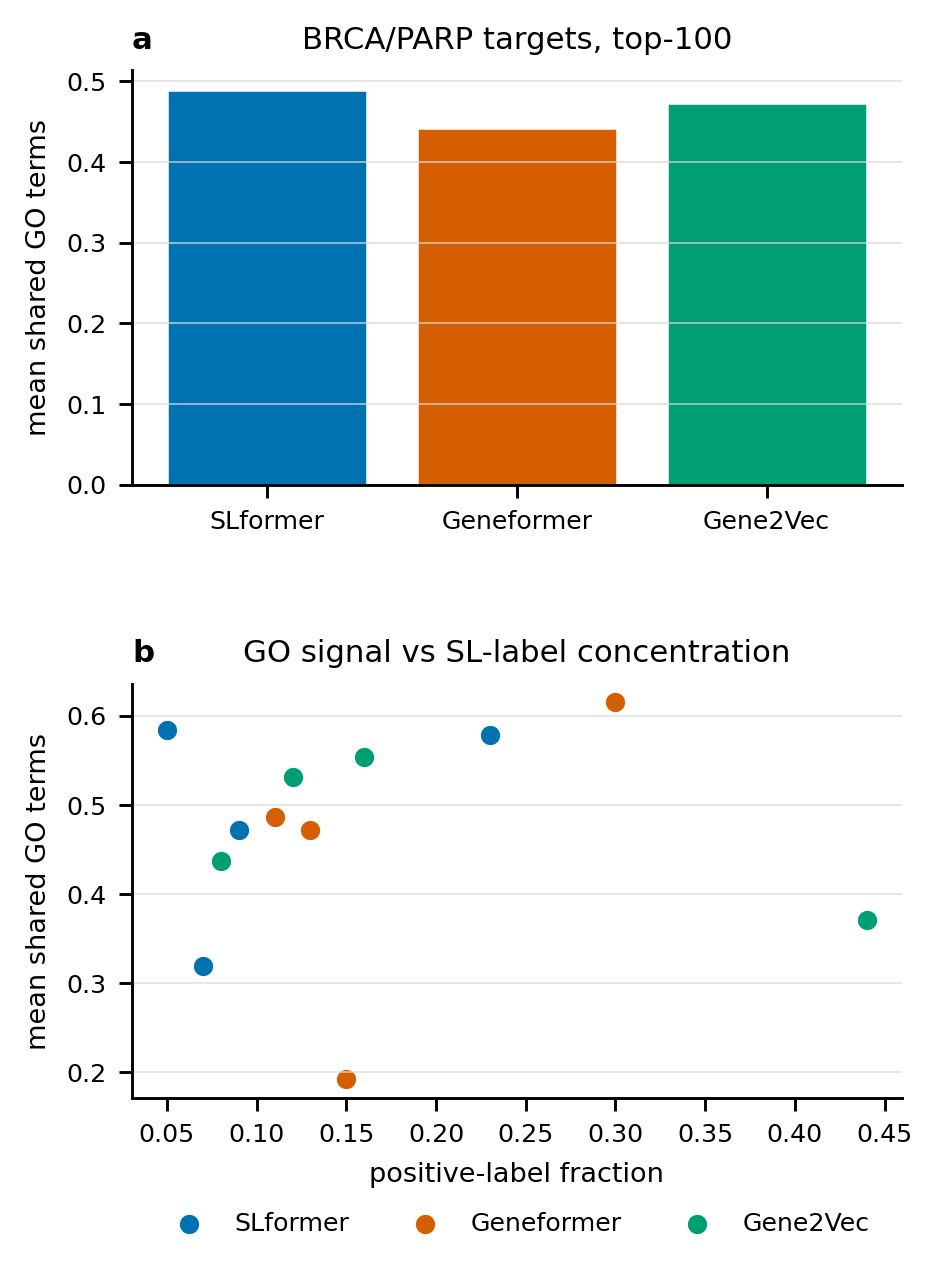

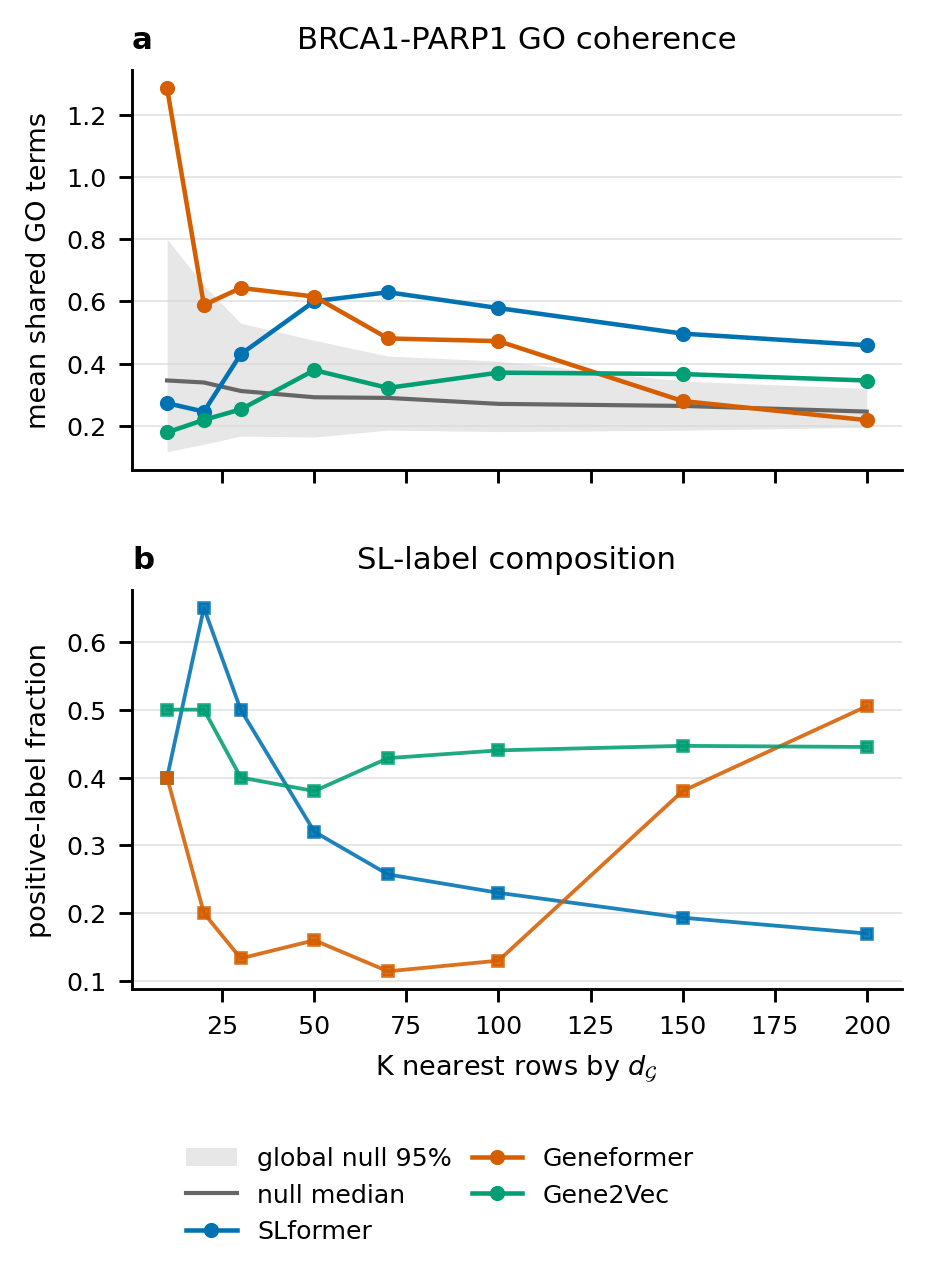

In [7]:
fig = plot_mapper_model_summary(
    cluster_best,
    target_k_summary,
    k=TARGET_SUMMARY_K,
    # out_path=PROJECT_ROOT / "output" / "SAE" / "figures" / "mapper_model_summary.svg",
)
plt.show()

brca1_coherence = coherence_with_null.query("target_pair == 'BRCA1-PARP1'").copy()
fig = plot_brca1_mapper_panel(
    brca1_coherence,
    null_summary,
    # out_path=PROJECT_ROOT / "output" / "SAE" / "figures" / "brca1_mapper_panel.svg",
)
plt.show()


## Mapper Permutation Stress Test

Shuffle scores before fitting the score-conditioned mapper and evaluate the resulting order with original scores.

In [8]:
target_indices_for_stress = [
    find_pair_index(meta_aligned, primary_gene, partner_gene, cancer)
    for primary_gene, partner_gene, cancer in TARGET_PAIRS
]
permutation_observed_parts = []
permutation_null_parts = []
for model_name, X_model in model_matrices.items():
    observed, null = mapper_permutation_stress_test(
        X_model,
        scores,
        labels,
        target_indices=target_indices_for_stress,
        model=model_name,
        ks=PERMUTATION_KS,
        fit_k=FIT_K,
        n_permutations=N_PERMUTATIONS,
        seed=SEED,
        tangent_dim=MANIFOLD_TANGENT_DIM,
        ridge_rho=MANIFOLD_RIDGE_RHO,
        nerve_lens_dims=MANIFOLD_NERVE_LENS_DIMS,
        nerve_covers=MANIFOLD_NERVE_COVERS,
        nerve_overlap=MANIFOLD_NERVE_OVERLAP,
        nerve_cover_mode=MANIFOLD_NERVE_COVER_MODE,
        nerve_cover_core_fraction=MANIFOLD_NERVE_COVER_CORE_FRACTION,
        nerve_cluster_mode=MANIFOLD_NERVE_CLUSTER_MODE,
        nerve_dbscan_eps_quantile=MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE,
        nerve_dbscan_min_samples=MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES,
        nerve_fallback_unreachable=MANIFOLD_NERVE_FALLBACK_UNREACHABLE,
    )
    permutation_observed_parts.append(observed)
    permutation_null_parts.append(null)

permutation_observed = pd.concat(permutation_observed_parts, ignore_index=True)
permutation_null = pd.concat(permutation_null_parts, ignore_index=True)
permutation_summary = summarize_permutation_stress(permutation_observed, permutation_null)
display(permutation_summary.round(4))


,model,k,observed_rho_score,observed_rho_label,observed_positive_fraction,observed_mean_score,null_rho_score_median,null_rho_score_q025,null_rho_score_q975,null_rho_label_median,null_positive_fraction_median,null_mean_score_median,rho_score_excess,label_fraction_excess
0,Gene2Vec,10,0.2333,0.0232,0.2250,0.2169,0.0303,-0.5164,0.6245,0.0870,0.0000,0.0730,0.2030,0.2250
1,Gene2Vec,30,0.1400,0.0638,0.1750,0.1734,0.0776,-0.3035,0.5094,0.0194,0.0667,0.0909,0.0624,0.1083
2,Gene2Vec,70,0.0276,-0.0269,0.1821,0.1864,-0.0369,-0.3766,0.2570,-0.0995,0.1000,0.1145,0.0645,0.0821
3,Gene2Vec,100,-0.0106,-0.0887,0.2000,0.1958,-0.0301,-0.2527,0.2609,-0.0467,0.1100,0.1160,0.0196,0.0900
4,Geneformer,10,-0.0545,0.0856,0.3750,0.3610,0.1030,-0.5294,0.6006,0.0580,0.2500,0.2244,-0.1576,0.1250
5,Geneformer,30,0.2910,0.2734,0.2417,0.2448,0.1097,-0.3479,0.3902,0.0441,0.1667,0.2045,0.1813,0.0750
6,Geneformer,70,0.1388,0.1799,0.1821,0.1655,0.0140,-0.2135,0.3282,0.0449,0.1714,0.1975,0.1248,0.0107
7,Geneformer,100,0.1031,0.1094,0.1725,0.1539,0.0584,-0.1435,0.2898,0.0544,0.1650,0.1697,0.0447,0.0075
8,SLformer,10,0.0182,-0.1682,0.1500,0.1329,0.0121,-0.6606,0.5758,-0.0380,0.2000,0.0539,0.0061,-0.0500
9,SLformer,30,-0.1165,-0.0339,0.2167,0.1731,0.0029,-0.5458,0.7874,0.1473,0.1667,0.0738,-0.1194,0.0500


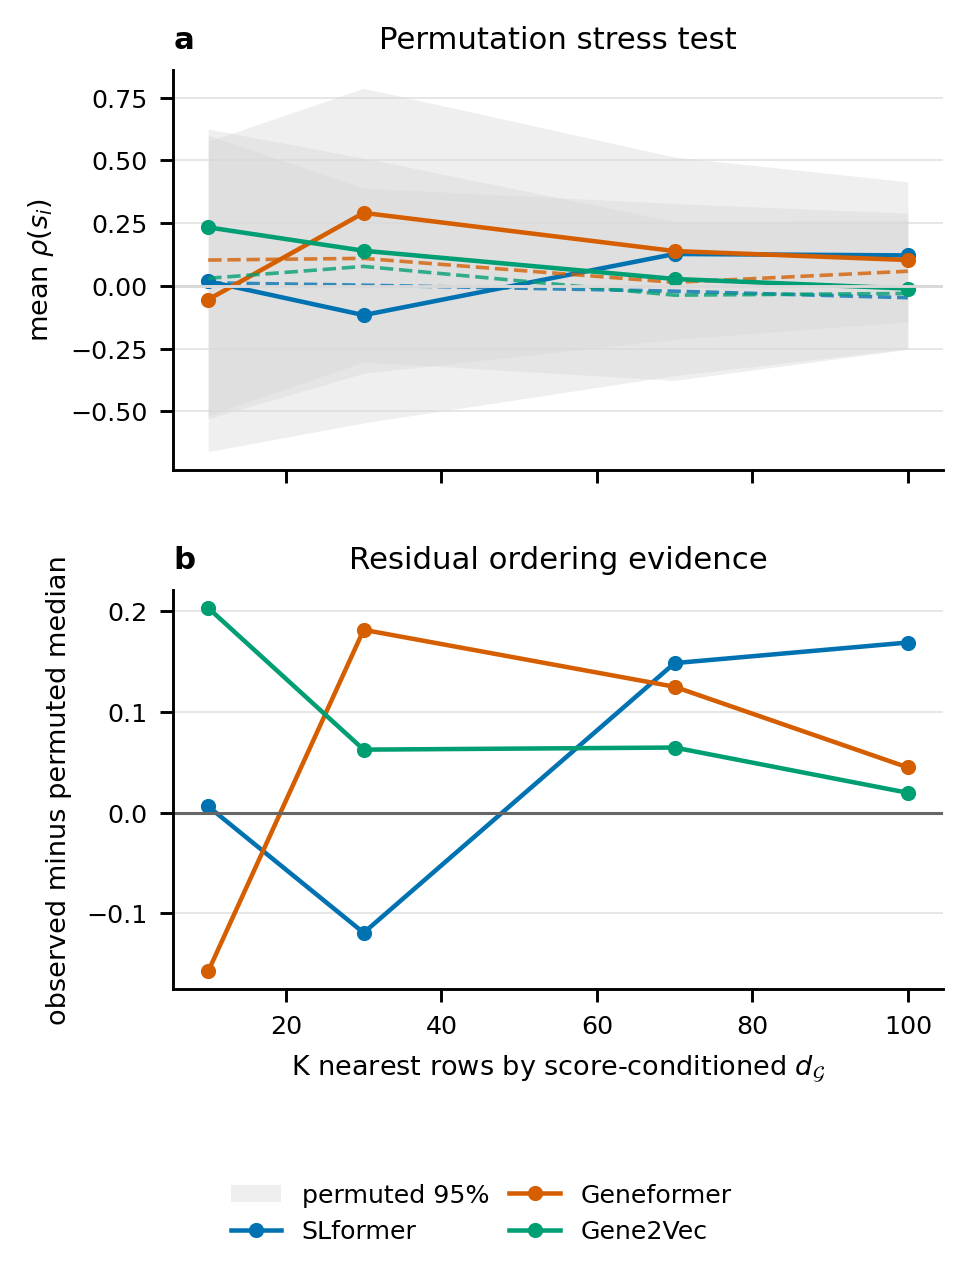

In [9]:
fig = plot_permutation_stress(
    permutation_summary,
    # out_path=PROJECT_ROOT / "output" / "SAE" / "figures" / "mapper_permutation_stress.svg",
)
plt.show()
